In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# Setting Parameters

Modeling Assumptions:
- Assume each acquisition of each slice is independent of all others, and its label is drawn from $\sim Ber(p)$

Setting Parameters:
- $p_b = 1/5$. The probability that a slice is bad (positive)
- $FPR$ and $TPR$ are variable
- $s$. Number of slices in a stack 
- $q = 1 - p_{req}$. Probability that a given slice does NOT to be re-acquired


Total # of re-acquisitions = sum of $~Geom(q)~$ $\rightarrow NegBin(s, q)$

In [121]:
num_sample_points = 50

In [122]:
p_b = 1.0/5
s = 30
FPR = np.linspace(0, 1, num = num_sample_points)[None, :] # row vec
TPR = np.linspace(0, 1, num = num_sample_points)[:, None] # column vec

In [123]:
q = 1 - (p_b * TPR + (1 - p_b) * FPR)# (num_sample_points x num_sample_points); (FPR, TPR)
q = q.clip(0.01, 1)

expected_reacquisition_count = s * (1-q) / q # formula for expectation

$color∝
\frac{log(max)−log(min)} 
{log(x)−log(min)}$
	​

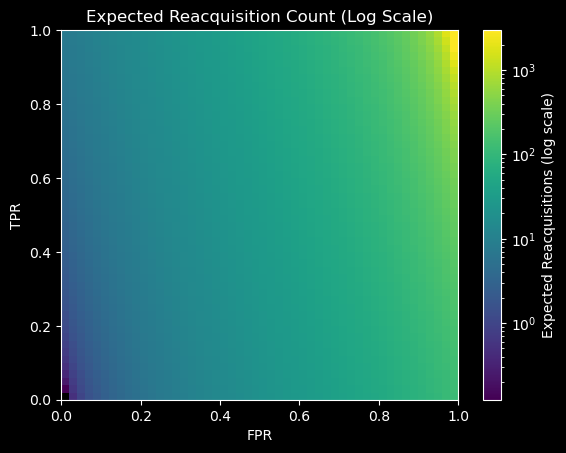

In [124]:
plt.imshow(expected_reacquisition_count, origin='lower', extent=[0,1,0,1],
           aspect='auto', norm = LogNorm()) # takes log and then 

plt.colorbar(label='Expected Reacquisitions (log scale)')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('Expected Reacquisition Count (Log Scale)')
plt.show()

Sampling for specific choice of FPR and TPR

In [136]:
def plot_samples(fpr_i, tpr_j, num_samples = 500):
    samples = np.random.negative_binomial(
    s,
    q,
    size=(num_samples, *q.shape)
    )[:, fpr_i, tpr_j]

    fpr_val, tpr_val = FPR.squeeze()[fpr_i], TPR.squeeze()[tpr_j]

    plt.hist(samples, density=True)

    plt.xlim(0, 100)

    plt.xlabel('Reacquisition Count')
    plt.ylabel('Density')
    plt.title(f'Histogram @ FPR={fpr_val:.2f}, TPR={tpr_val:.2f}')

    plt.show()

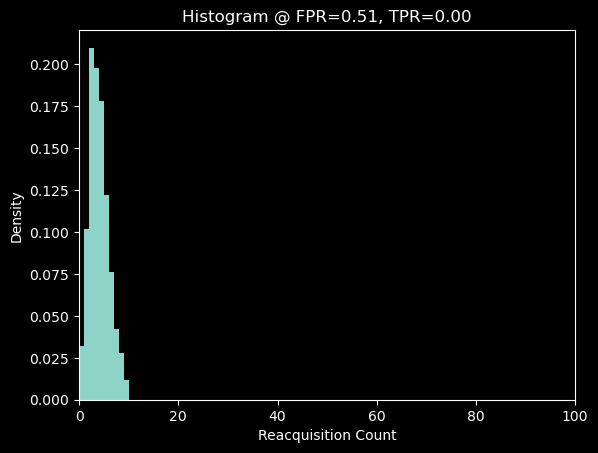

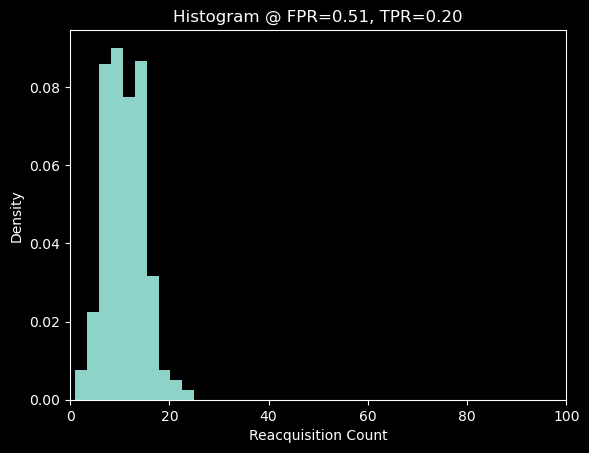

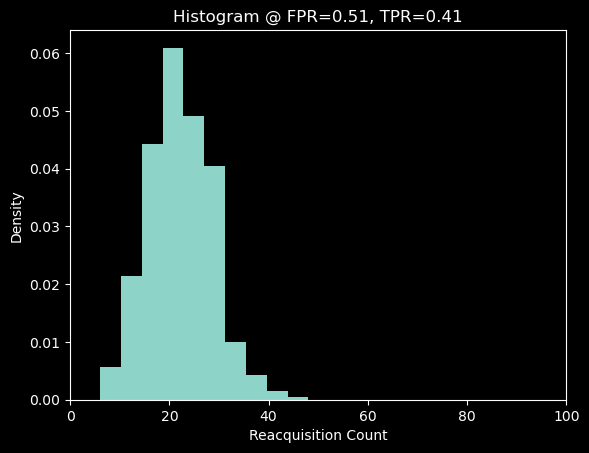

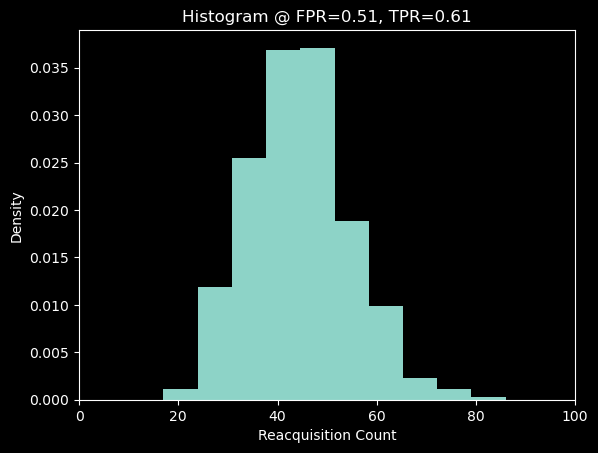

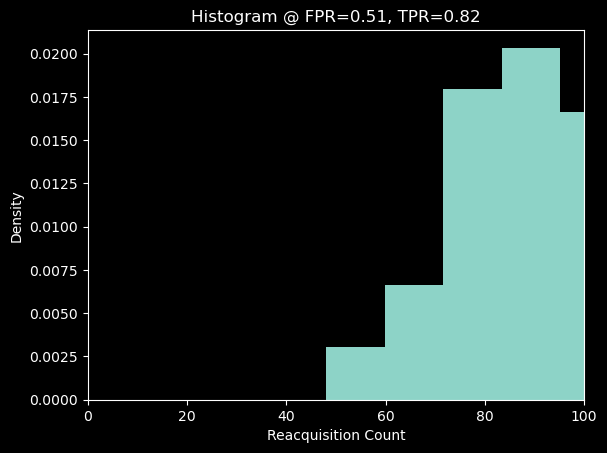

In [138]:
for tpr in range(0, 50, 10):
    plot_samples(25, tpr)

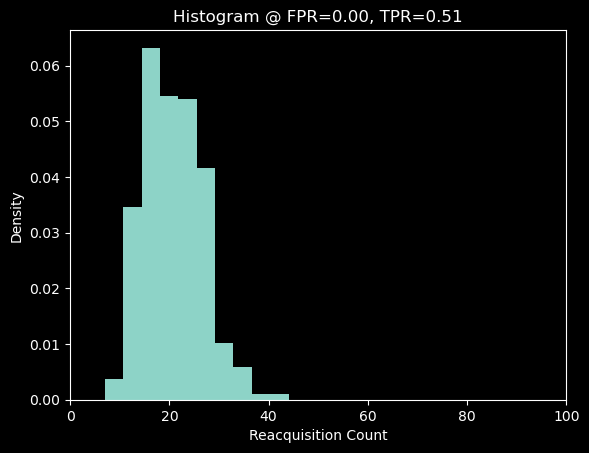

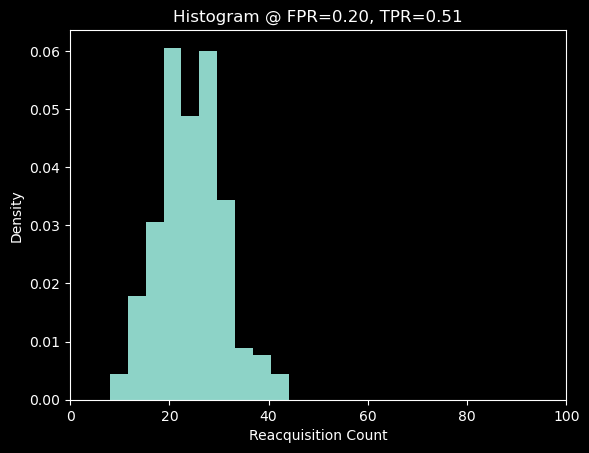

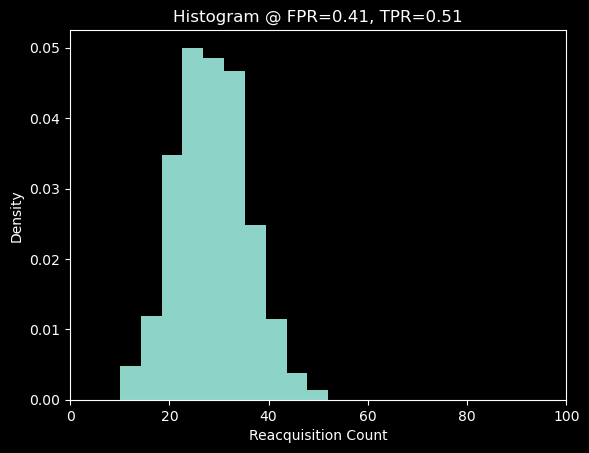

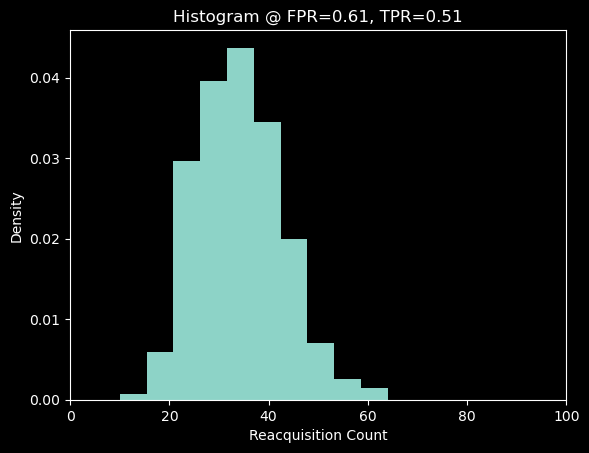

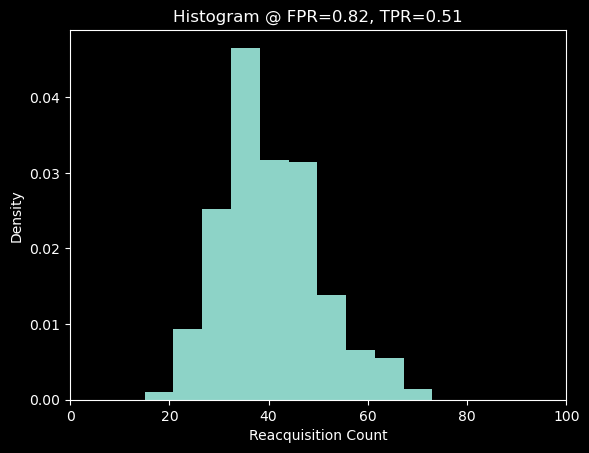

In [139]:
for fpr in range(0, 50, 10):
    plot_samples(fpr, 25)